In [4]:
pip install langchain

  Using cached langchain-1.3.14-py3-none-any.whl.metadata (6.1 kB)
Using cached langchain-1.3.14-py3-none-any.whl (139 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.messages import RemoveMessage

In [6]:
load_dotenv()

True

In [7]:
model = ChatGroq(model="llama-3.3-70b-versatile")

In [8]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [9]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [10]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [11]:
graph = builder.compile(checkpointer=InMemorySaver())

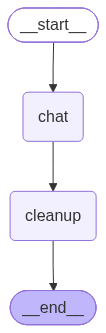

In [12]:
graph

In [13]:
config = {"configurable": {"thread_id": "t1"}}

In [14]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Nitish"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='a614357a-1cd5-4d40-b295-d10cd8a4956f'),
  AIMessage(content='LangChain is an open-source framework designed to simplify the development and deployment of large language models (LLMs) like LangGraph. It provides a unified interface for interacting with LLMs, allowing developers to build applications and workflows that leverage the capabilities of these models.\n\n**What does LangChain do?**\n\nLangChain acts as a bridge between the LLM and the application or workflow that wants to use it. It provides a set of tools and APIs that make it easy to:\n\n1. **Interact with LLMs**: LangChain provides a standardized interface for interacting with LLMs, allowing developers to send requests and receive responses from the model.\n2. **Manage LLM deployments**: LangChain provides tools for deploying and managing LLMs in various environments, such as cloud platforms, on-premises servers, or edge d

In [15]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
